In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv('/content/healthcare_dataset.csv')

In [ ]:
data

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
0,1,31,18.3,1.5,0,119.1,0
1,2,44,26.3,3.1,0,120.5,0
2,3,43,24.2,4.8,0,130.3,0
3,4,32,25.0,6.0,0,119.5,0
4,5,28,22.1,4.2,1,127.4,0
...,...,...,...,...,...,...,...
5995,5996,52,24.6,2.7,0,128.6,0
5996,5997,66,26.9,1.2,1,139.8,0
5997,5998,19,23.6,6.7,0,116.6,0
5998,5999,51,29.7,1.7,0,129.7,0


In [ ]:
print("Dataset Shape:")
print(data.shape)

Dataset Shape:
(6000, 7)


In [ ]:
print("Column Types:")
print(data.info())

Column Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               6000 non-null   int64  
 1   age                      6000 non-null   int64  
 2   bmi                      6000 non-null   float64
 3   exercise_hours_per_week  6000 non-null   float64
 4   smoker                   6000 non-null   int64  
 5   blood_pressure           6000 non-null   float64
 6   diabetes                 6000 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 328.3 KB
None


In [ ]:
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
patient_id                 0
age                        0
bmi                        0
exercise_hours_per_week    0
smoker                     0
blood_pressure             0
diabetes                   0
dtype: int64


In [ ]:
print("Basic Statistical Analysis:")
print(data.describe())

Basic Statistical Analysis:
        patient_id          age          bmi  exercise_hours_per_week  \
count  6000.000000  6000.000000  6000.000000              6000.000000   
mean   3000.500000    51.107333    25.995267                 3.012800   
std    1732.195139    19.522722     4.960541                 1.491802   
min       1.000000    18.000000    15.000000                 0.000000   
25%    1500.750000    34.000000    22.500000                 2.000000   
50%    3000.500000    51.000000    26.100000                 3.000000   
75%    4500.250000    68.000000    29.400000                 4.000000   
max    6000.000000    84.000000    44.900000                 8.500000   

            smoker  blood_pressure     diabetes  
count  6000.000000     6000.000000  6000.000000  
mean      0.307000      134.239733     0.090333  
std       0.461288       11.234260     0.286683  
min       0.000000       94.000000     0.000000  
25%       0.000000      126.000000     0.000000  
50%       0.00

In [ ]:
data['diabetes'].value_counts()

,count
diabetes,
0,5458
1,542


Count of smokers/non-smokers by diabetes status:
diabetes     0    1
smoker             
0         3777  381
1         1681  161

Percentage of diabetics among smokers vs non-smokers:
diabetes         0         1
smoker                      
0         0.908369  0.091631
1         0.912595  0.087405


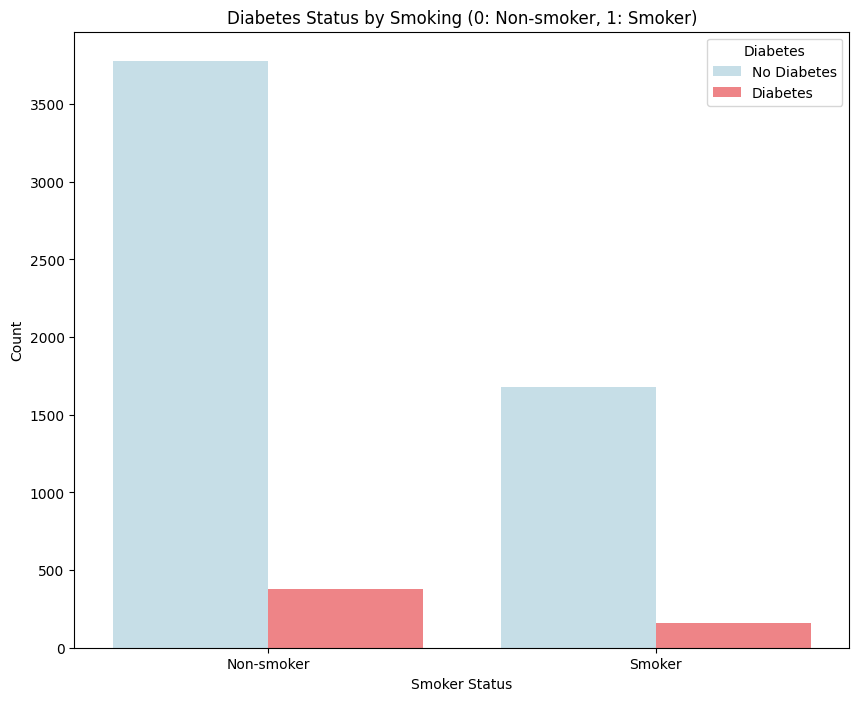

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

smoker_diabetes_counts = pd.crosstab(data['smoker'], data['diabetes'])
print("Count of smokers/non-smokers by diabetes status:")
print(smoker_diabetes_counts)

print("\nPercentage of diabetics among smokers vs non-smokers:")
# Calculate the percentage of diabetics within each smoker group
smoker_diabetes_percentage = smoker_diabetes_counts.apply(lambda r: r / r.sum(), axis=1)
print(smoker_diabetes_percentage)

plt.figure(figsize=(10,8))
sns.countplot(data=data, x='smoker', hue='diabetes', palette=['#c1e1ec','#FF7377'])
plt.title('Diabetes Status by Smoking (0: Non-smoker, 1: Smoker)')
plt.xlabel('Smoker Status')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Non-smoker', 'Smoker'])
plt.legend(title='Diabetes', labels=['No Diabetes', 'Diabetes'])
plt.show()

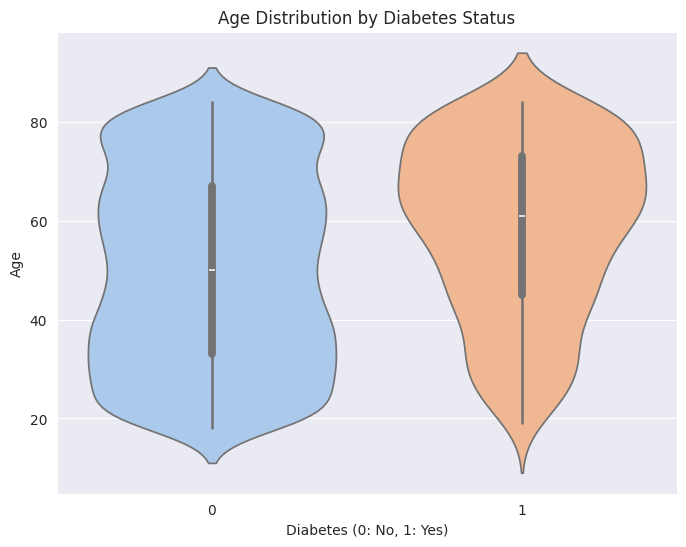

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.figure(figsize=(8, 6))
sns.violinplot(x='diabetes', y='age', data=data, hue='diabetes', palette='pastel', legend=False)
plt.title('Age Distribution by Diabetes Status')
plt.xlabel('Diabetes (0: No, 1: Yes)')
plt.ylabel('Age')
plt.show()

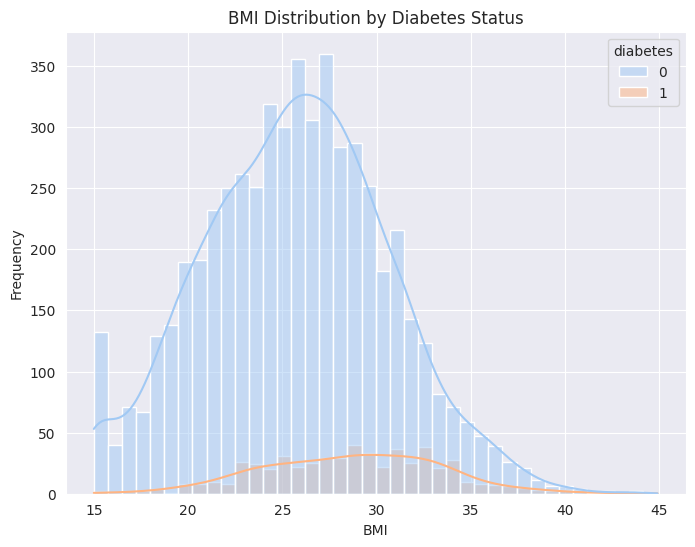

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(data=data, x='bmi', hue='diabetes', kde=True, palette='pastel')
plt.title('BMI Distribution by Diabetes Status')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

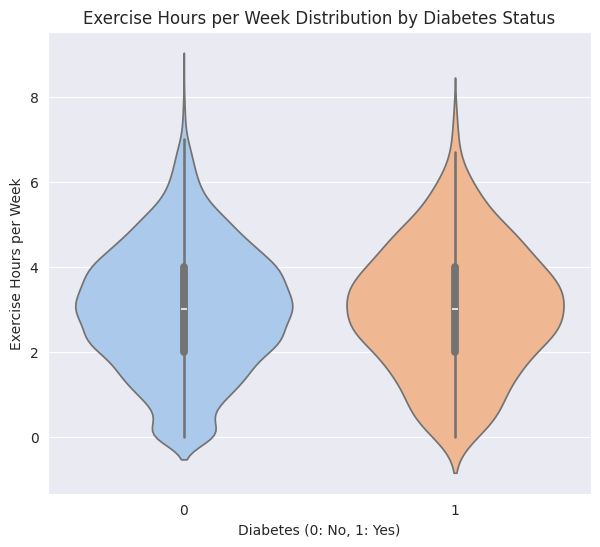

In [ ]:
plt.figure(figsize=(7, 6))
sns.violinplot(x='diabetes', y='exercise_hours_per_week', data=data, hue='diabetes', palette='pastel', legend=False)
plt.title('Exercise Hours per Week Distribution by Diabetes Status')
plt.xlabel('Diabetes (0: No, 1: Yes)')
plt.ylabel('Exercise Hours per Week')
plt.show()


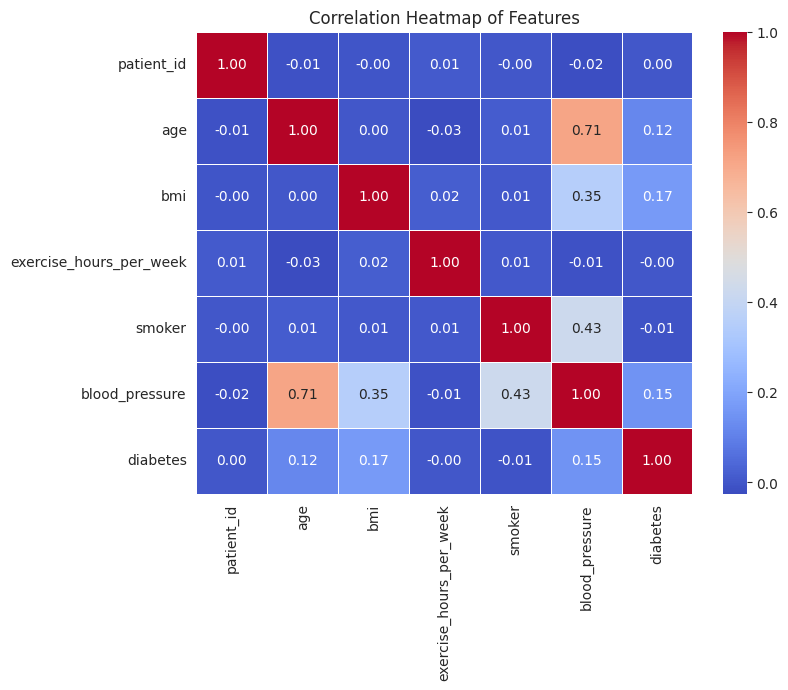

In [ ]:
plt.figure(figsize=(8,6))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Features')
plt.show()

## **1.Separate features (X) and target variable (y)**


In [ ]:
X = data.drop(['diabetes', 'patient_id'], axis=1)
y = data['diabetes']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (6000, 5)
Target (y) shape: (6000,)


# **2.Perform train-test split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4800, 5)
X_test shape: (1200, 5)
y_train shape: (4800,)
y_test shape: (1200,)


# **3.Feature scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (4800, 5)
X_test_scaled shape: (1200, 5)


# **4. Train a Logistic Regression classifier**

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, class_weight='balanced')

# Train the model on the scaled training data
log_reg_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


# 5. Generate **predictions**

In [ ]:
y_pred = log_reg_model.predict(X_test_scaled)
print("Predictions generated.")

Predictions generated.


# 6. Evaluate model **performance**

In [ ]:
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 6. Evaluate Performance
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.65
Precision: 0.15
Recall: 0.63
F1 Score: 0.24

Confusion Matrix:
[[712 380]
 [ 40  68]]


<Figure size 700x500 with 0 Axes>

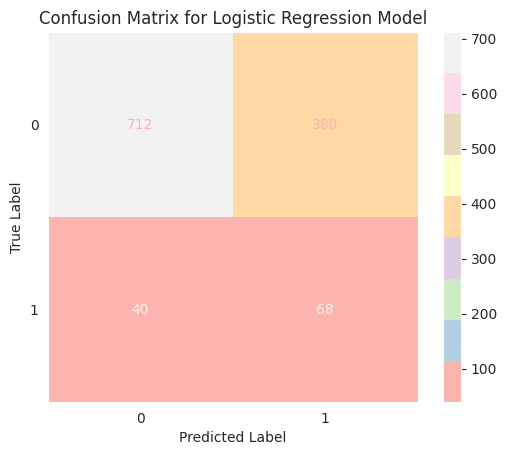

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix for the Logistic Regression model
cm_log_reg = confusion_matrix(y_test, y_pred)

# Create a ConfusionMatrixDisplay
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=[0, 1])

# Plot the confusion matrix
plt.figure(figsize=(7,5))
disp_log_reg.plot(cmap='Pastel1', values_format='d')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)
plt.show()

In [ ]:
# Create a DataFrame to display feature names and their corresponding coefficients
feature_names = X.columns
coefficients = log_reg_model.coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Importance': np.abs(coefficients)
})

# Sort by importance to see the strongest predictors at the top
importance_df = importance_df.sort_values(by='Absolute_Importance', ascending=False)

print("--- Logistic Regression Feature Importance ---")
print(importance_df[['Feature', 'Coefficient']])

--- Logistic Regression Feature Importance ---
                   Feature  Coefficient
1                      bmi     0.524337
0                      age     0.337278
4           blood_pressure     0.272897
3                   smoker    -0.175619
2  exercise_hours_per_week     0.032847


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Create a Sequential neural network model
# 2. Add layers:
#    a. Input layer (number of features in X_train_scaled)
#    b. Hidden layers (two hidden layers with ReLU activation)
#    c. Output layer (single neuron with sigmoid activation for binary classification)
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],), name='input'),
    layers.Dense(64, activation='relu', name='hiddenlayer1'),
    layers.Dense(32, activation='relu', name='hiddenlayer2'),
    layers.Dense(1, activation='sigmoid', name='output')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hiddenlayer1 (Dense)            │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hiddenlayer2 (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# 3. Compile model using:
#    a. Adam optimizer
#    b. Binary crossentropy loss
#    c. Metrics: accuracy, precision, recall
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# 4. Train the model
#    Using X_train_scaled and y_train
history = model.fit(
    X_train_scaled, y_train,
    epochs=20,  # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_split=0.2 # Use 20% of training data for validation

)

Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8893 - loss: 0.3546 - val_accuracy: 0.9083 - val_loss: 0.2905
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9099 - loss: 0.2896 - val_accuracy: 0.9083 - val_loss: 0.2837
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9099 - loss: 0.2855 - val_accuracy: 0.9083 - val_loss: 0.2829
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9099 - loss: 0.2843 - val_accuracy: 0.9083 - val_loss: 0.2834
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9099 - loss: 0.2818 - val_accuracy: 0.9083 - val_loss: 0.2843
Epoch 6/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9099 - loss: 0.2823 - val_accuracy: 0.9083 - val_loss: 0.2822
Epoch 7/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9099 - loss: 0.2802 - val_accuracy: 0.9083 - val_loss: 0.2807
Epoch 8/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9099 - loss: 0.2794 - val_accuracy: 0.

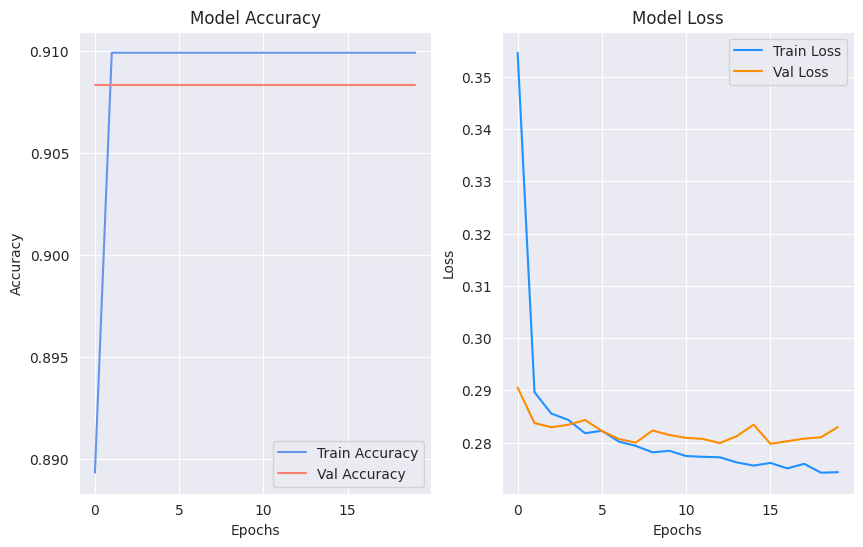

In [ ]:
import matplotlib.pyplot as plt

# Adjust the figure size
plt.figure(figsize=(10, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='cornflowerblue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='salmon')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='dodgerblue')
plt.plot(history.history['val_loss'], label='Val Loss', color='darkorange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:

# 5. Evaluate performance on test data
loss, accuracy= model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\nANN Model Performance on Test Data:")
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")

y_pred_ann = (model.predict(X_test_scaled) > 0.5).astype("int32")
print("\nConfusion Matrix for ANN:")
print(confusion_matrix(y_test, y_pred_ann))
print("\nClassification Report for ANN:")
print(classification_report(y_test, y_pred_ann))


ANN Model Performance on Test Data:
Loss: 0.2853
Accuracy: 0.9100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Confusion Matrix for ANN:
[[1092    0]
 [ 108    0]]

Classification Report for ANN:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1092
           1       0.00      0.00      0.00       108

    accuracy                           0.91      1200
   macro avg       0.46      0.50      0.48      1200
weighted avg       0.83      0.91      0.87      1200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 1000x600 with 0 Axes>

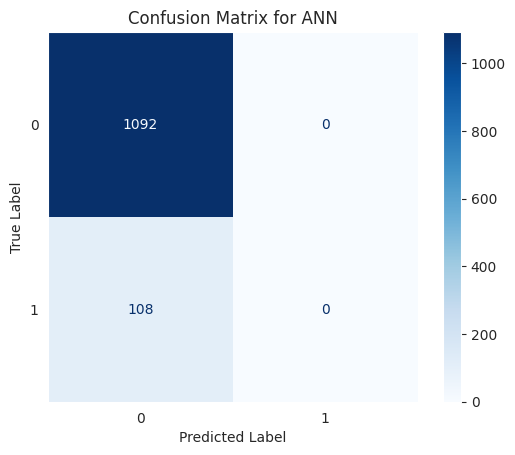

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix for the ANN model with class weights
cm_ann_weighted = confusion_matrix(y_test, y_pred_ann)

# Create a ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ann_weighted, display_labels=[0, 1]) # Assuming 0: No Diabetes, 1: Diabetes

# Plot the confusion matrix
plt.figure(figsize=(10, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for ANN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)
plt.show()
